Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing and encoding categorical features...
Features after encoding: 64

Treinando classificador binário
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Classe Binária ---
              precision    recall  f1-score   support

  Normal (0)       0.74      0.86      0.80     30351
  Ataque (1)       0.85      0.72      0.78     32916

    accuracy                           0.79     63267
   macro avg       0.79      0.79      0.79     63267
weighted avg       0.80      0.79      0.79     63267



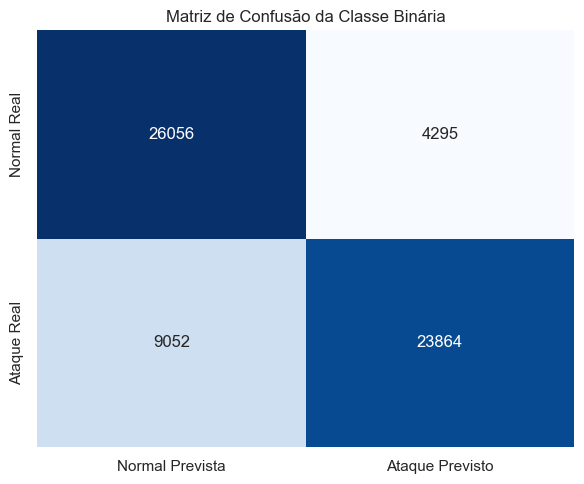


Treinando o Classificador Multi-Classe (Attack_Cat)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Multiclasse ---
                precision    recall  f1-score   support

      Analysis       0.46      0.10      0.17      3990
           DoS       1.00      1.00      1.00     11847
      Exploits       0.68      0.23      0.34      8192
       Fuzzers       0.43      0.30      0.36      4085
        Normal       0.71      0.94      0.81     30351
Reconnaissance       0.88      0.80      0.84      4802

      accuracy                           0.76     63267
     macro avg       0.69      0.56      0.59     63267
  weighted avg       0.74      0.76      0.72     63267



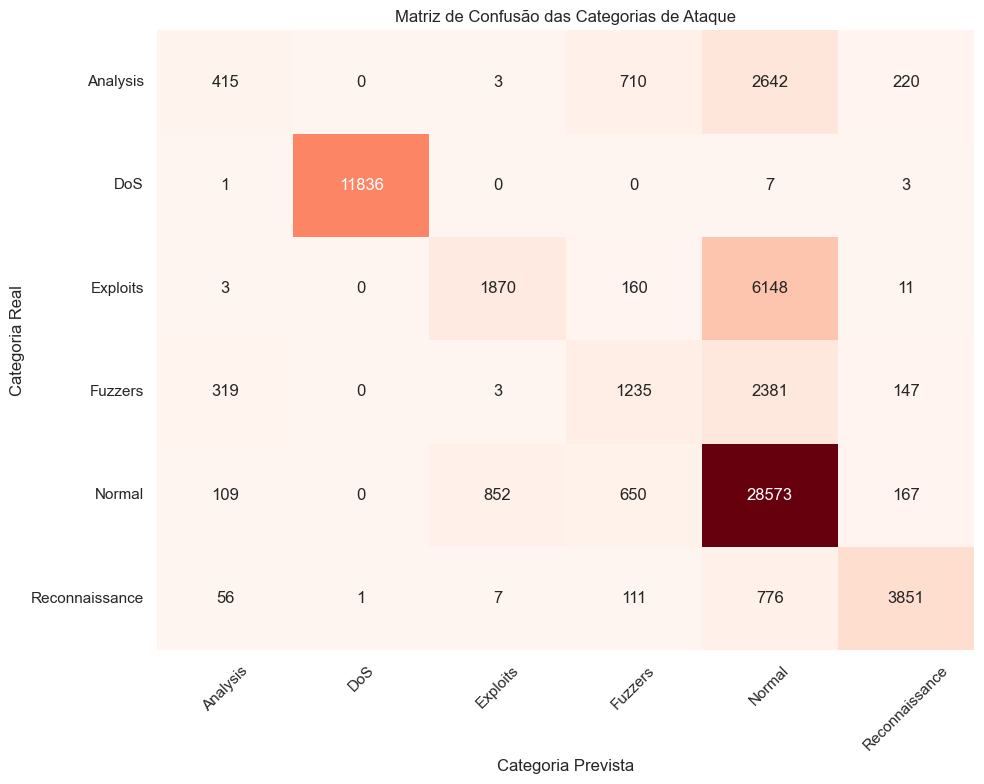


Top 10 Features Mais Importantes
         Feature  Importancia
      ct_srv_dst     0.133412
ct_dst_sport_ltm     0.061417
             dur     0.049995
          synack     0.046839
           smean     0.045201
          sinpkt     0.041752
      ct_srv_src     0.039577
            sjit     0.036885
          sbytes     0.035622
           sload     0.032334


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING & ENCODING
# ==========================================
print("\nPreprocessing and encoding categorical features...")

# Define targets and the specific network identity/time columns that ML cannot process
targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']

# Combine them into a single list of columns to drop safely
drop_cols = targets + identities

# Separate features (X) and targets (y), ignoring columns if they were already dropped
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']
y_train_multi = train_df['attack_cat']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']
y_test_multi = test_df['attack_cat']

# Categorical columns to encode
cat_cols = ['proto', 'service', 'state']

# Apply One-Hot Encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Align Train and Test columns (crucial if some categories only exist in one set)
# Fill missing columns in test set with 0
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Features after encoding: {X_train_encoded.shape[1]}")

# ==========================================
# 3. BINARY CLASSIFICATION (Attack vs Normal)
# ==========================================
print("\n" + "="*50)
print("Treinando classificador binário")
print("="*50)

# Initialize Random Forest with balanced class weights
rf_bin = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1 # Uses all available CPU cores
)

print("Fazendo fit no modelo...")
rf_bin.fit(X_train_encoded, y_train_bin)

print("Predizendo no conjunto de teste...")
y_pred_bin = rf_bin.predict(X_test_encoded)

# Binary Metrics
print("\n--- Relatório - Classe Binária ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Binary Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão da Classe Binária')
plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTI-CLASS CLASSIFICATION (Attack Categories)
# ==========================================
print("\n" + "="*50)
print("Treinando o Classificador Multi-Classe (Attack_Cat)")
print("="*50)

# Initialize a new Random Forest for multi-class
rf_multi = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

print("Fazendo fit no modelo...")
rf_multi.fit(X_train_encoded, y_train_multi)

print("Predizendo no conjunto de teste...")
y_pred_multi = rf_multi.predict(X_test_encoded)

# Multi-Class Metrics
print("\n--- Relatório - Multiclasse ---")
print(classification_report(y_test_multi, y_pred_multi))

# Multi-Class Confusion Matrix
plt.figure(figsize=(10, 8))
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

# Get unique classes present in the test set to label the axes correctly
labels = sorted(y_test_multi.unique())

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão das Categorias de Ataque')
plt.xlabel('Categoria Prevista')
plt.ylabel('Categoria Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (Optional but highly recommended)
# ==========================================
print("\n" + "="*50)
print("Top 10 Features Mais Importantes")
print("="*50)

feature_importances = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importancia': rf_multi.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(feature_importances.head(10).to_string(index=False))